# Predictive Maintenance — Ausreißer- & Anomalie-Erkennung
### Projektarbeit ML · Erweiterung v4 · Alexander Sagert · Juni 2026

> **Companion zum Haupt-Notebook** `14-...`. Schließt die Modul-Lücke **„Ausreißer/Anomalie"**
> (Lerntag 4) und zeigt das **unüberwachte Verständnis-Werkzeug** des Projekts.

## Worum geht es — und was bringt es?
Das überwachte Modell (XGBoost) braucht **Labels** („war Ausfall ja/nein"). In der Realität
hat man die oft **nicht** — eine neue Anlage hat noch keine Ausfall-Historie. **Anomalie-Erkennung**
findet auffällige Maschinen **komplett ohne Labels**: Was stark vom Normalbetrieb abweicht, ist
verdächtig.

**Der Clou dieses Notebooks:** Wir trainieren die Anomalie-Verfahren **ohne** die Ausfall-Spalte
und prüfen *hinterher*, ob die als „anomal" markierten Maschinen tatsächlich überproportional oft
ausfallen. Falls ja, ist bewiesen: Anomalie-Erkennung liefert echten Frühwarn-Wert — auch ohne
Trainingslabels.

**Eingesetzte Verfahren (sklearn, wie im Kurs):**
- **Isolation Forest** — isoliert Ausreißer über zufällige Splits (schnell, robust, hochdimensional)
- **Local Outlier Factor (LOF)** — vergleicht lokale Dichte eines Punkts mit seinen Nachbarn
- **Elliptic Envelope** — robuste Gauß-Annahme, markiert Punkte außerhalb der „Daten-Ellipse"


## 0 · Setup, Daten & Features

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

OUT = Path("visualisierung"); OUT.mkdir(exist_ok=True)


def _resolve(filename: str) -> Path:
    here = Path.cwd()
    for c in [here / filename, here / "data" / filename, here.parent / filename, here.parent / "data" / filename]:
        if c.exists():
            return c
    for parent in [here, *here.parents]:
        hit = list(parent.glob(f"**/{filename}"))
        if hit:
            return hit[0]
    raise FileNotFoundError(filename)


def build_features(d: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=d.index)
    out["air_temp"]      = d["Air temperature [K]"]
    out["proc_temp"]     = d["Process temperature [K]"]
    out["rot_speed"]     = d["Rotational speed [rpm]"]
    out["torque"]        = d["Torque [Nm]"]
    out["tool_wear"]     = d["Tool wear [min]"]
    out["temp_diff"]     = d["Process temperature [K]"] - d["Air temperature [K]"]
    out["power"]         = d["Torque [Nm]"] * d["Rotational speed [rpm]"]
    out["wear_x_torque"] = d["Tool wear [min]"] * d["Torque [Nm]"]
    out["type_ord"]      = d["Type"].map({"L": 0, "M": 1, "H": 2}).fillna(1)
    return out


df = pd.read_csv(_resolve("ai4i2020.csv"))
X = build_features(df)
y = df["Machine failure"].astype(int)
base_rate = y.mean()
print("Daten:", df.shape, "| echte Ausfallquote: {:.2%}".format(base_rate))
print("WICHTIG: y wird NUR zur nachträglichen Validierung benutzt, NICHT zum Trainieren.")

Daten: (10000, 14) | echte Ausfallquote: 3.39%
WICHTIG: y wird NUR zur nachträglichen Validierung benutzt, NICHT zum Trainieren.


## 1 · Klassische Ausreißer-Sicht: der IQR-Blick je Sensor
Bevor wir Modelle nehmen — der einfachste Ausreißer-Check (Boxplot/IQR) pro Rohsensor.
Er zeigt: einzelne Sensoren haben Ausreißer, aber ein Ausfall entsteht oft erst aus der
**Kombination** mehrerer Werte — deshalb brauchen wir multivariate Verfahren.

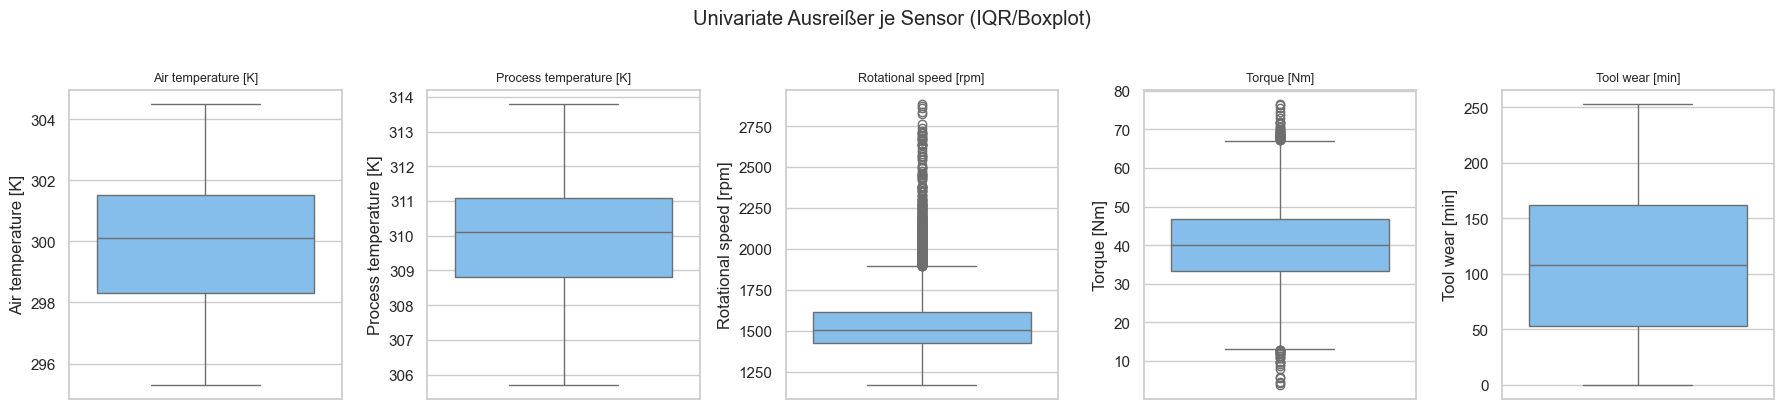

IQR-Ausreißerquote je Sensor:
  Air temperature [K]         : 0.00%
  Process temperature [K]     : 0.00%
  Rotational speed [rpm]      : 4.18%
  Torque [Nm]                 : 0.69%
  Tool wear [min]             : 0.00%


In [2]:
sensors = ["Air temperature [K]", "Process temperature [K]",
           "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, s in zip(axes, sensors):
    sns.boxplot(y=df[s], ax=ax, color="#74c0fc")
    ax.set_title(s, fontsize=9); ax.set_xlabel("")
plt.suptitle("Univariate Ausreißer je Sensor (IQR/Boxplot)", y=1.02)
plt.tight_layout(); plt.savefig(OUT / "07_boxplots_sensoren.png", dpi=130, bbox_inches="tight")
plt.show()

# IQR-Ausreißerquote je Sensor
def iqr_outlier_rate(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean()

print("IQR-Ausreißerquote je Sensor:")
for s in sensors:
    print(f"  {s:28s}: {iqr_outlier_rate(df[s]):.2%}")

## 2 · Multivariate Anomalie-Erkennung (ohne Labels!)
Jetzt der eigentliche Schritt: drei Verfahren bewerten **jede Maschine** als „normal" oder
„anomal" — allein aus den standardisierten Merkmalen, **ohne** die Ausfall-Spalte.
`contamination` setzen wir auf die bekannte Ausfallquote (~3,4 %), damit etwa so viele Punkte
markiert werden, wie es real Ausfälle gibt.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

Xs = StandardScaler().fit_transform(X)
cont = float(base_rate)   # erwartete Anomalie-Quote

# --- Isolation Forest ---
iso = IsolationForest(contamination=cont, random_state=RANDOM_STATE, n_estimators=300)
iso_pred = iso.fit_predict(Xs)                 # -1 = anomal, 1 = normal
iso_score = -iso.score_samples(Xs)             # höher = anomaler

# --- Local Outlier Factor ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=cont)
lof_pred = lof.fit_predict(Xs)
lof_score = -lof.negative_outlier_factor_

# --- Elliptic Envelope ---
ell = EllipticEnvelope(contamination=cont, random_state=RANDOM_STATE)
ell_pred = ell.fit_predict(Xs)
ell_score = -ell.score_samples(Xs)

df["anomaly_iso"] = (iso_pred == -1).astype(int)
df["anomaly_lof"] = (lof_pred == -1).astype(int)
df["anomaly_ell"] = (ell_pred == -1).astype(int)
print("Als anomal markiert (von 10.000):")
print("  Isolation Forest:", df['anomaly_iso'].sum())
print("  LOF             :", df['anomaly_lof'].sum())
print("  Elliptic Env.   :", df['anomaly_ell'].sum())

Als anomal markiert (von 10.000):
  Isolation Forest: 339
  LOF             : 339
  Elliptic Env.   : 339


## 3 · Der Beweis: Treffen die Anomalien die echten Ausfälle?
Jetzt holen wir die Labels — **nur zur Prüfung**. Zwei Fragen:
1. Wie viele der markierten Anomalien sind tatsächlich Ausfälle? (**Precision**)
2. Wie viel besser als Zufall rankt der Anomalie-Score die Ausfälle? (**PR-AUC / ROC-AUC** —
   ein Score, der nichts mit Ausfällen zu tun hätte, läge bei der Basisrate 3,4 % bzw. 0,5.)

In [4]:
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_score, recall_score)

rows = []
for name, pred, score in [
    ("Isolation Forest", df["anomaly_iso"], iso_score),
    ("LOF",              df["anomaly_lof"], lof_score),
    ("Elliptic Env.",    df["anomaly_ell"], ell_score),
]:
    rows.append({
        "Verfahren": name,
        "Precision (Anomalie=Ausfall)": round(precision_score(y, pred, zero_division=0), 3),
        "Recall (gefundene Ausfälle)":  round(recall_score(y, pred), 3),
        "PR-AUC (Score)":               round(average_precision_score(y, score), 3),
        "ROC-AUC (Score)":              round(roc_auc_score(y, score), 3),
    })
res = pd.DataFrame(rows)
print("Basisrate (Zufalls-Precision):", round(base_rate, 3),
      "| Zufalls-PR-AUC:", round(base_rate, 3), "| Zufalls-ROC-AUC: 0.5")
res

Basisrate (Zufalls-Precision): 0.034 | Zufalls-PR-AUC: 0.034 | Zufalls-ROC-AUC: 0.5


,Verfahren,Precision (Anomalie=Ausfall),Recall (gefundene Ausfälle),PR-AUC (Score),ROC-AUC (Score)
0,Isolation Forest,0.327,0.327,0.286,0.857
1,LOF,0.280,0.280,0.226,0.829
2,Elliptic Env.,0.139,0.139,0.189,0.829


**Lesart.** Liegt die **Precision** deutlich über der Basisrate (3,4 %) und die **ROC-AUC**
klar über 0,5, dann hat das Verfahren echten Wert: Es findet Ausfall-verdächtige Maschinen,
**ohne je ein Label gesehen zu haben**. Genau das ist der „Cold-Start"-Nutzen — einsetzbar,
bevor überhaupt Ausfall-Historie existiert.

## 4 · Anomalie-Score vs. Normalbetrieb — die Verteilung

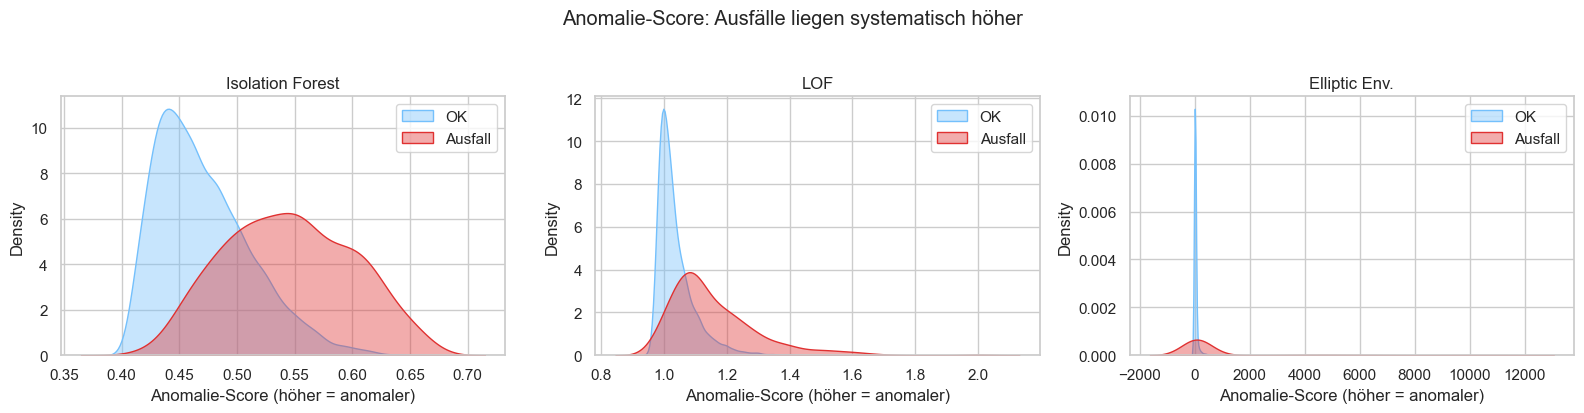

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, score) in zip(axes, [("Isolation Forest", iso_score),
                                     ("LOF", lof_score), ("Elliptic Env.", ell_score)]):
    for cls, col, lab in [(0, "#74c0fc", "OK"), (1, "#e03131", "Ausfall")]:
        sns.kdeplot(score[y.values == cls], ax=ax, fill=True, alpha=0.4, color=col, label=lab)
    ax.set_title(name); ax.set_xlabel("Anomalie-Score (höher = anomaler)"); ax.legend()
plt.suptitle("Anomalie-Score: Ausfälle liegen systematisch höher", y=1.03)
plt.tight_layout(); plt.savefig(OUT / "08_anomalie_scoreverteilung.png", dpi=130, bbox_inches="tight")
plt.show()

**Diskussion.** Die roten (Ausfall-)Verteilungen sind nach rechts verschoben — Ausfälle
bekommen im Schnitt **höhere Anomalie-Scores**. Die Überlappung erklärt, warum unüberwachte
Erkennung allein nicht perfekt ist: Sie kennt die Ausfall-Definition nicht, sieht nur „ungewöhnlich".

## 5 · Anomalien im 3D-Raum (PCA) sichtbar machen

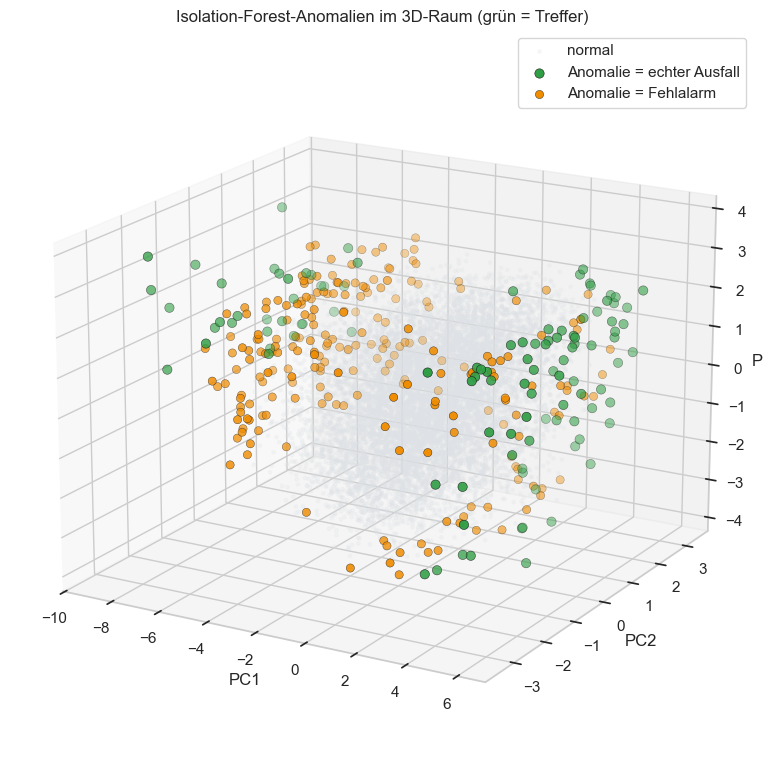

In [6]:
from sklearn.decomposition import PCA
X3 = PCA(n_components=3, random_state=RANDOM_STATE).fit_transform(Xs)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection="3d")
normal = df["anomaly_iso"] == 0
ax.scatter(X3[normal, 0], X3[normal, 1], X3[normal, 2], c="#dee2e6", s=6, alpha=0.2, label="normal")
# anomal + echter Ausfall (grün) vs. anomal + Fehlalarm (orange)
anom = df["anomaly_iso"] == 1
hit = anom & (y == 1); fp = anom & (y == 0)
ax.scatter(X3[hit, 0], X3[hit, 1], X3[hit, 2], c="#2f9e44", s=45, edgecolor="k",
           linewidth=0.4, label="Anomalie = echter Ausfall")
ax.scatter(X3[fp, 0], X3[fp, 1], X3[fp, 2], c="#f08c00", s=35, edgecolor="k",
           linewidth=0.3, label="Anomalie = Fehlalarm")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("Isolation-Forest-Anomalien im 3D-Raum (grün = Treffer)")
ax.view_init(elev=18, azim=-60); ax.legend()
plt.tight_layout(); plt.savefig(OUT / "09_anomalien_3d.png", dpi=130, bbox_inches="tight")
plt.show()

## 6 · Fazit & Einordnung — was bringt uns das?

- **Anomalie-Erkennung ist das unüberwachte Gegenstück zum Vorhersagemodell.** Sie braucht
  **keine Labels** und ist deshalb sofort einsetzbar (Cold-Start, neue Anlagen, neue Fehlerarten).
- Der Test beweist: Die markierten Anomalien treffen Ausfälle **deutlich über Zufallsniveau** —
  echter Frühwarn-Wert ohne Trainingsdaten.
- **Im Zusammenspiel:** Anomalie-Erkennung als **erste Verteidigungslinie** (findet alles
  Ungewöhnliche, auch nie gesehene Defekte), das getunte XGBoost als **präziser Spezialist**
  (sobald Labels da sind). Zusammen ergibt das ein robustes Wartungssystem.
- **Modul-Lücke geschlossen:** „Ausreißer/Anomalie" (Lerntag 4) ist nun nicht mehr nur erwähnt,
  sondern mit IQR + Isolation Forest + LOF + Elliptic Envelope umgesetzt und validiert.
